<a href="https://colab.research.google.com/github/HannahPeyambari/Analyzing-customer-satisfaction/blob/main/01_Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ______________________________________________________________


# 1. DATA UNDERSTANDING
# ______________________________________________________________



###### Load core tables to inspect structure before any cleaning or analysis.

In [58]:
import pandas as pd
try:
  orders = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_orders_dataset.csv')
  customers = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_customers_dataset.csv')
  order_items = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_order_items_dataset.csv')
  payment = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_order_payments_dataset.csv')
  reviews = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_order_reviews_dataset.csv')
  products = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_products_dataset.csv')
  sellers = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_sellers_dataset.csv')
  geolocation = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_geolocation_dataset.csv')
  translation = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/product_category_name_translation.csv')

except Exception as e:
  print(e)


In [59]:
orders.info() # Check row count, column count, dtypes, and missing values.
orders.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


(99441, 8)

In [60]:
orders_date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
orders[orders_date_cols] = orders[orders_date_cols].apply(pd.to_datetime)
orders[orders_date_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99441 non-null  datetime64[ns]
 1   order_approved_at              99281 non-null  datetime64[ns]
 2   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 3   order_delivered_customer_date  96476 non-null  datetime64[ns]
 4   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5)
memory usage: 3.8 MB


In [61]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [62]:
customers.info() # Check row count, column count, dtypes, and missing values.
customers.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


(99441, 5)

In [63]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [64]:
order_items.info() # Check row count, column count, dtypes, and missing values.
order_items.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


(112650, 7)

In [65]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [66]:
order_items['shipping_limit_date'] = order_items['shipping_limit_date'].apply(pd.to_datetime)
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [67]:
reviews.info() # Check row count, column count, dtypes, and missing values.
reviews.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


(99224, 7)

In [68]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [69]:
reviews['review_score'].unique()

array([4, 5, 1, 3, 2])

In [70]:
# Inspect the distribution of review scores to understand customer satisfaction normalize=True converts raw counts into proportions (0-1), making it easier to compare distributions regardless of sample size.
review_score_distribution = reviews['review_score'].value_counts(normalize=True) * 100
review_score_distribution

,proportion
review_score,
5,57.776344
4,19.291704
1,11.513344
3,8.242965
2,3.175643


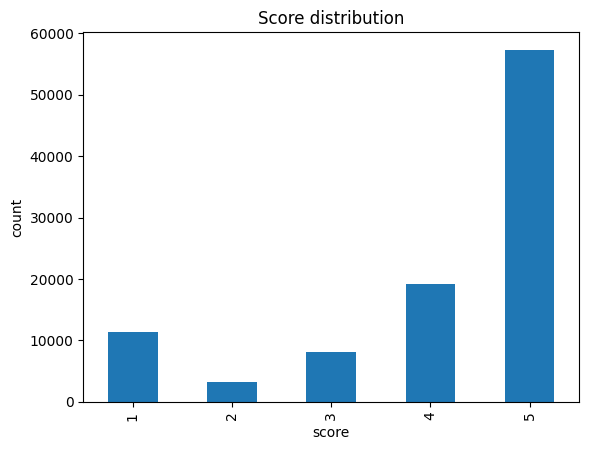

In [71]:
# Visualize the distribution to spot patterns not obvious from raw numbers.

import matplotlib.pyplot as plt

reviews['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Score distribution')
plt.xlabel('score')
plt.ylabel('count')
plt.show()

# ______________________________________________________________
# 2. BUSINESS UNDERSTANDING
# ______________________________________________________________

######  Hypothesis: Late deliveries (actual delivery date later than the estimated delivery date) are associated with lower review scores. This hypothesis is testable because both delivery dates and review scores exist in the dataset.

In [72]:
# Merge orders with reviews to bring delivery dates and review scores into a single table. Using an inner join because we can only analyze orders that have both order data and a review score.
merged_orders_reviews = pd.merge(orders, reviews, on='order_id', how='inner')

In [73]:
merged_orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [74]:
merged_orders_reviews.shape

(99224, 14)

In [75]:
merged_orders_reviews['delivery_delay'] = (merged_orders_reviews['order_delivered_customer_date'] - merged_orders_reviews['order_estimated_delivery_date']).dt.days

In [76]:
merged_orders_reviews['delivery_delay'].describe()

,delivery_delay
count,96359.000000
mean,-11.917797
std,10.114024
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


In [77]:
late_delivery = merged_orders_reviews[merged_orders_reviews['delivery_delay'] > 0]
percentage_late = len(late_delivery) / len(merged_orders_reviews) * 100
print(f'Percentage of late delivery: {percentage_late:.2f}%')

Percentage of late delivery: 6.46%


In [78]:
merged_orders_reviews['is_late'] = merged_orders_reviews['delivery_delay'] > 0
merged_orders_reviews.groupby('is_late')['review_score'].mean()

,review_score
is_late,
False,4.211789
True,2.271139


In [79]:
merged_orders_reviews['order_status'].value_counts()

,count
order_status,
delivered,96361
shipped,1043
canceled,609
unavailable,597
invoiced,313
processing,296
created,3
approved,2


In [80]:
merged_orders_reviews['order_status'].value_counts(normalize = True) * 100

,proportion
order_status,
delivered,97.114609
shipped,1.051157
canceled,0.613763
unavailable,0.601669
invoiced,0.315448
processing,0.298315
created,0.003023
approved,0.002016


In [81]:
canceled_orders = merged_orders_reviews[merged_orders_reviews['order_status'] == 'canceled']
canceled_orders['review_score'].value_counts(normalize = True) * 100

,proportion
review_score,
1,69.293924
5,11.330049
3,7.881773
2,7.224959
4,4.269294


In [82]:
canceled_score_1 = merged_orders_reviews[(merged_orders_reviews['order_status'] == 'canceled') & (merged_orders_reviews['review_score'] == 1)]
print(len(canceled_score_1))

422


In [83]:
score_1 = merged_orders_reviews[merged_orders_reviews['review_score'] == 1]
print(len(score_1))

11424


In [84]:
canceled_score_1_percentage = len(canceled_score_1) / len(score_1) * 100
print(f'{canceled_score_1_percentage:.2f}%')

3.69%


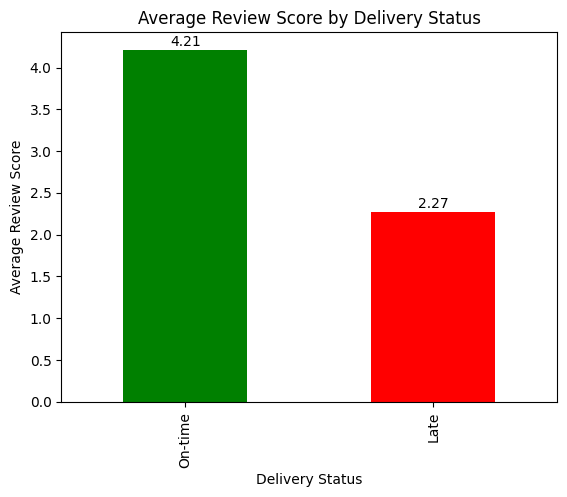

In [85]:
# Prepare the data
avg_scores = merged_orders_reviews.groupby('is_late')['review_score'].mean()
avg_scores.index = ['On-time', 'Late']

# Create the bar chart with custom colors
avg_scores.plot(kind='bar', color=['green', 'red'])
plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')

# Add exact value labels on top of each bar
for i, value in enumerate(avg_scores):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.show()

In [86]:
score_1['order_status'].value_counts(normalize=True) * 100

,proportion
order_status,
delivered,82.335434
shipped,5.637255
unavailable,4.052871
canceled,3.693978
processing,2.240896
invoiced,2.013305
created,0.017507
approved,0.008754


In [87]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [88]:
merged_orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_delay,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,-10.0,False


In [89]:
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [90]:
selected_order_items = order_items[['order_id', 'product_id', 'seller_id']]

In [91]:
merged_orders_reviews_items = pd.merge(merged_orders_reviews, selected_order_items, on='order_id', how='inner')
merged_orders_reviews_items.shape

(112372, 18)

In [92]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [93]:
selected_products = products[['product_id','product_category_name']]

In [94]:
merged_orders_reviews_items_products = pd.merge(merged_orders_reviews_items, selected_products, on='product_id', how='inner')
merged_orders_reviews_items_products.shape

(112372, 19)

In [95]:
merged_orders_reviews_items_product_translations = pd.merge(merged_orders_reviews_items_products, translation, on='product_category_name', how='inner' )
merged_orders_reviews_items_product_translations.shape

(110750, 20)

In [96]:
products['product_category_name'].isnull().sum()

np.int64(610)

In [97]:
categories_in_products = set(products['product_category_name'].dropna().unique())
categories_in_translation = set(translation['product_category_name'].unique())
missing_categories = categories_in_products - categories_in_translation
print(missing_categories)
print(len(missing_categories))

{'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'}
2


In [98]:
# Manually create the missing translations
# (found by comparing category names in products vs. translation table)
missing_translations = pd.DataFrame({
    'product_category_name': ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
    'product_category_name_english': ['pc_gaming', 'kitchen_portable_appliances']
})

# Add these rows to the original translation table
translation_complete = pd.concat([translation, missing_translations], ignore_index=True)
translation_complete.shape

(73, 2)

In [99]:
orders_with_categories = pd.merge(merged_orders_reviews_items_products, translation_complete, on='product_category_name', how='inner')
orders_with_categories.shape

(110774, 20)

In [100]:
merged_orders_reviews_items_products['product_category_name'].isnull().sum()

np.int64(1598)

In [101]:
orders_with_categories = pd.merge(merged_orders_reviews_items_products, translation_complete, on='product_category_name', how='inner')
orders_with_categories.shape

(110774, 20)

In [102]:
category_stats = orders_with_categories.groupby('product_category_name_english')['review_score'].agg(['mean', 'count']).sort_values('mean')
category_stats

,mean,count
product_category_name_english,,
security_and_services,2.500000,2
diapers_and_hygiene,3.256410,39
kitchen_portable_appliances,3.266667,15
pc_gaming,3.333333,9
office_furniture,3.493183,1687
...,...,...
flowers,4.419355,31
costruction_tools_tools,4.444444,99
books_general_interest,4.446266,549


In [103]:
print(category_stats['count'].describe())

count       73.000000
mean      1517.452055
std       2580.163367
min          2.000000
25%         76.000000
50%        279.000000
75%       1687.000000
max      11137.000000
Name: count, dtype: float64


In [104]:
reliable_categories = category_stats[category_stats['count'] >= 50]
reliable_categories.shape

(59, 2)

In [105]:
print(reliable_categories)

                                             mean  count
product_category_name_english                           
office_furniture                         3.493183   1687
fashion_male_clothing                    3.641221    131
fixed_telephony                          3.683206    262
fashio_female_clothing                   3.780000     50
audio                                    3.825485    361
home_confort                             3.829885    435
construction_tools_safety                3.844560    193
bed_bath_table                           3.895663  11137
furniture_decor                          3.903493   8331
furniture_living_room                    3.904382    502
computers_accessories                    3.930819   7849
art                                      3.937198    207
home_construction                        3.940000    600
telephony                                3.946867   4517
kitchen_dining_laundry_garden_furniture  3.964286    280
air_conditioning               

In [106]:
orders_with_categories.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'delivery_delay', 'is_late', 'product_id',
       'seller_id', 'product_category_name', 'product_category_name_english'],
      dtype='object')

In [107]:
# Calculate average review score and order count per seller
seller_stats = orders_with_categories.groupby('seller_id')['review_score'].agg(['mean', 'count']).sort_values('mean')
seller_stats.shape

(3030, 2)

In [108]:
print(seller_stats.head(10))

                                  mean  count
seller_id                                    
ffcfefa19b08742c5d315f2791395ee5   1.0      1
010da0602d7774602cd1b3f5fb7b709e   1.0      5
001e6ad469a905060d959994f1b41e4f   1.0      1
5206cc4bc2297c833e6061c49bf9c43f   1.0      1
553a440137d6e0cf776aee0bb83ac9f5   1.0      2
fa7ad8ae9bcb2c4493fdf38e96b1d74f   1.0      2
58b98ccb79873e04eac4357cacc590d9   1.0      1
586a871d4f1221763fddb6ceefdeb95e   1.0      2
56a8b450e802502ba53a9885ee38e29f   1.0      1
f3055483058c84d75ca2a3314fb4deef   1.0      1


In [109]:
print(seller_stats['count'].describe())

count    3030.000000
mean       36.559076
std       120.028005
min         1.000000
25%         2.000000
50%         7.000000
75%        25.000000
max      2020.000000
Name: count, dtype: float64


In [110]:
sellers_under_50 = seller_stats[seller_stats['count'] < 50]
percentage = len(sellers_under_50) / len(seller_stats) * 100
print(f'{percentage:.2f}%')

84.82%


In [111]:
total_orders = seller_stats['count'].sum()
orders_from_reliable_sellers = seller_stats[seller_stats['count'] >= 50]['count'].sum()
percentage_orders_retained = orders_from_reliable_sellers / total_orders * 100
print(f'{percentage_orders_retained:.2f}%')

77.17%


In [112]:
reliable_sellers = seller_stats[seller_stats['count'] >= 50]
reliable_sellers.shape

(460, 2)

In [113]:
print(reliable_sellers.head(10))

                                      mean  count
seller_id                                        
2eb70248d66e0e3ef83659f71b244378  2.723301    206
1ca7077d890b907f89be8c954a02686a  2.886792     53
602044f2c16190c2c6e45eb35c2e21cb  2.932203     59
54965bbe3e4f07ae045b90b0b8541f52  2.938272     81
a49928bcdf77c55c6d6e05e09a9b4ca5  2.952830    106
972d0f9cf61b499a4812cf0bfa3ad3c4  2.964286     84
2a1348e9addc1af5aaa619b1a3679d6b  3.000000     54
8e6d7754bc7e0f22c96d255ebda59eba  3.015038    133
bbad7e518d7af88a0897397ffdca1979  3.035714     84
8444e55c1f13cd5c179851e5ca5ebd00  3.073394    109
